<a href="https://colab.research.google.com/github/aruntakhur/DeepLearning_Aut_2020_IIITDWD/blob/master/GAN_On_Learning_Normal_Distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We import:

torch → core deep learning library \
nn → neural network modules \
optim → optimizers \
matplotlib → visualization

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

🧠 Explanation \
We create a fixed dataset of 1000 samples \
Distribution: mean = 4, std ≈ 1.5 \
This is our ground truth (p_data)

👉 Generator will try to learn this without knowing the formula.

In [65]:
torch.manual_seed(0)

real_dataset = torch.randn(1000, 1) * 1.5 + 4

🧠 Explanation \
Shows the true distribution \
Students see: “target shape the GAN must learn”

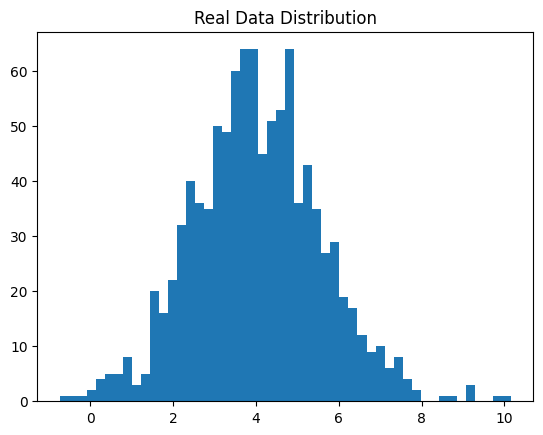

In [66]:
plt.hist(real_dataset.numpy(), bins=50)
plt.title("Real Data Distribution")
plt.show()

🧠 Explanation \
Takes random noise z \
Outputs a number (fake sample) \
Learns: \
👉 “Where should fake samples lie?”

In [67]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, z):
        return self.net(z)

G = Generator()

🧠 Explanation \
Input: data sample \
Output: probability (real or fake)

👉 Learns:

“Is this sample from real dataset?”

In [68]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

D = Discriminator()

🧠 Explanation \
Binary cross-entropy: \
Real → 1 \
Fake → 0 \
Two optimizers: \
One for Generator \
One for Discriminator

In [69]:
criterion = nn.BCELoss()

g_optimizer = optim.Adam(G.parameters(), lr=0.001)
d_optimizer = optim.Adam(D.parameters(), lr=0.001)

🧠 Explanation \
Generator is untrained \
Output is random \
Distribution will NOT match real data

👉 Important baseline

Before Training:
Mean: 0.108
Std: 0.061


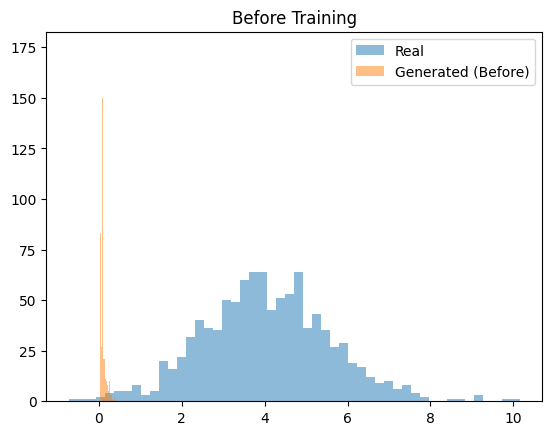

In [70]:
z = torch.randn(1000, 1)
generated_before = G(z).detach()

print("Before Training:")
print(f"Mean: {generated_before.mean().item():.3f}")
print(f"Std: {generated_before.std().item():.3f}")

plt.hist(real_dataset.numpy(), bins=50, alpha=0.5, label="Real")
plt.hist(generated_before.numpy(), bins=50, alpha=0.5, label="Generated (Before)")

plt.legend()
plt.title("Before Training")
plt.show()

Visualization Function

In [74]:
import matplotlib.pyplot as plt

def plot_distributions(G, real_dataset, epoch):
    z = torch.randn(1000, 1)
    generated = G(z).detach()

    plt.figure(figsize=(6,4))
    plt.hist(real_dataset.numpy(), bins=50, alpha=0.5, label="Real")
    plt.hist(generated.numpy(), bins=50, alpha=0.5, label="Generated")

    plt.title(f"Epoch {epoch}")
    plt.legend()
    plt.show()

🧠 Explanation

Each iteration:

Step 1: Train Discriminator \
Real → label 1 \
Fake → label 0 \
Step 2: Train Generator \
Trick: label fake as real (1)

👉 Forces generator to fool discriminator


Epoch 0
D Loss: 1.3661, G Loss: 0.8983


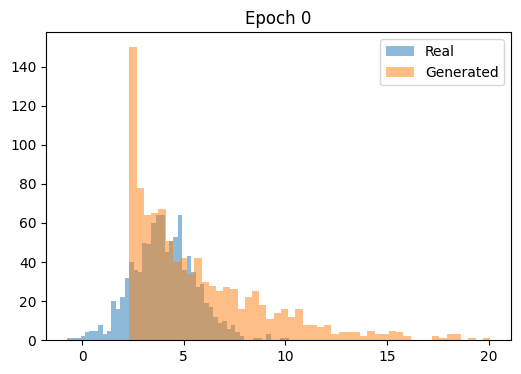


Epoch 200
D Loss: 1.4335, G Loss: 0.5865


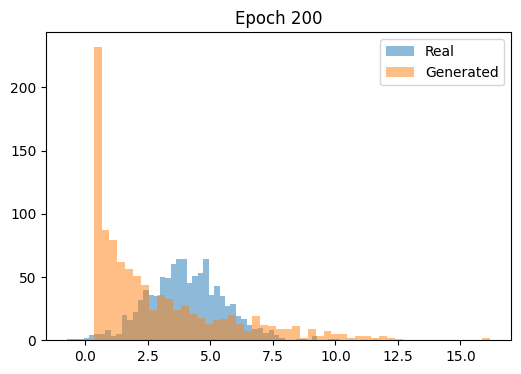


Epoch 400
D Loss: 1.3065, G Loss: 0.7621


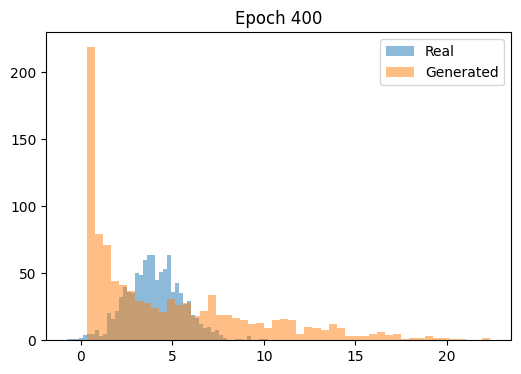


Epoch 600
D Loss: 1.4414, G Loss: 0.6444


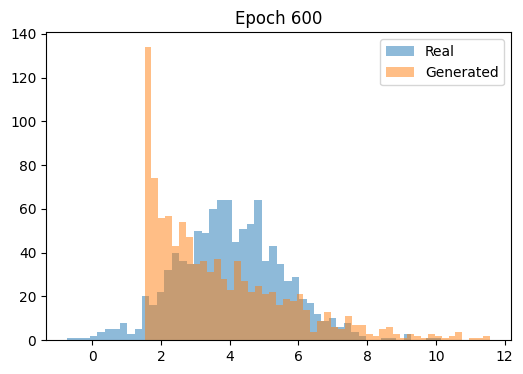


Epoch 800
D Loss: 1.3736, G Loss: 0.6987


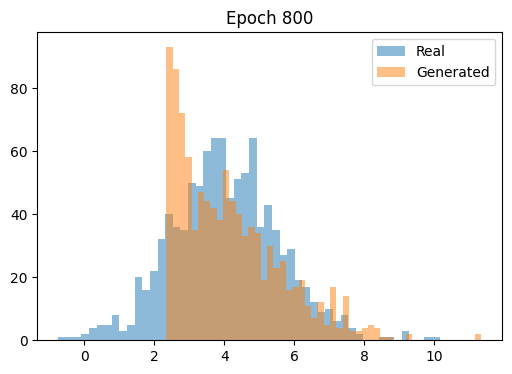


Epoch 1000
D Loss: 1.3953, G Loss: 0.6872


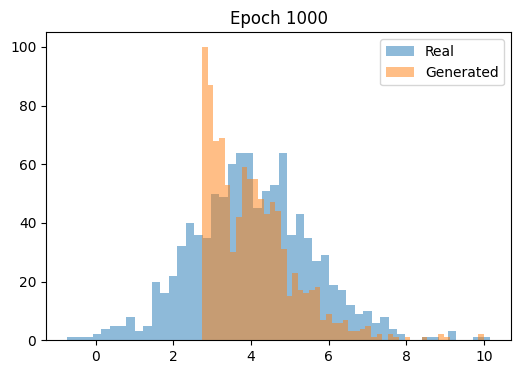


Epoch 1200
D Loss: 1.3982, G Loss: 0.6993


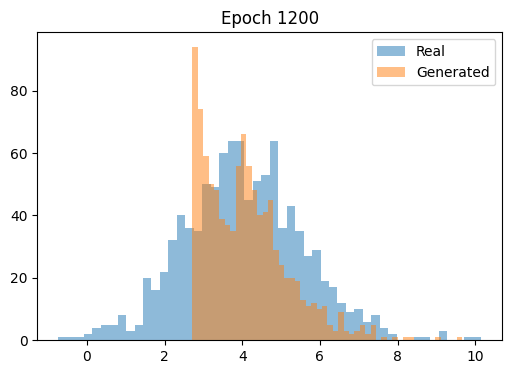


Epoch 1400
D Loss: 1.3942, G Loss: 0.6765


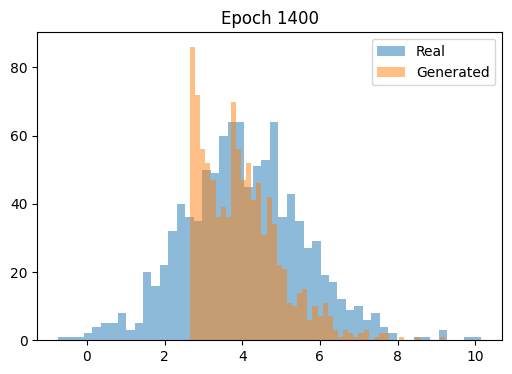


Epoch 1600
D Loss: 1.3904, G Loss: 0.6910


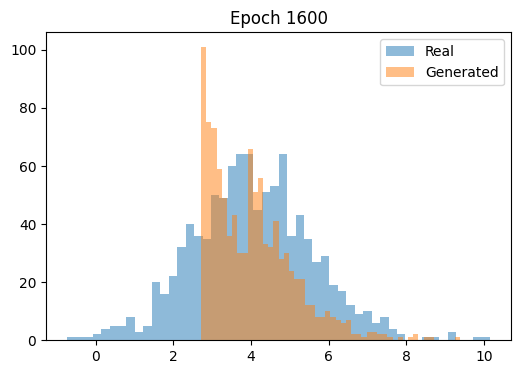


Epoch 1800
D Loss: 1.3869, G Loss: 0.6737


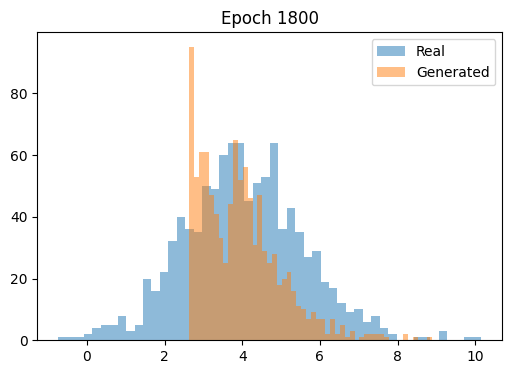

In [75]:
epochs = 2000
batch_size = 32

for epoch in range(epochs):

    # ---------------------
    # Sample real data
    # ---------------------
    idx = torch.randint(0, 1000, (batch_size,))
    real = real_dataset[idx]

    # Generate fake
    z = torch.randn(batch_size, 1)
    fake = G(z).detach()

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    # ---------------------
    # Train Discriminator
    # ---------------------
    d_real = D(real)
    d_fake = D(fake)

    d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # ---------------------
    # Train Generator
    # ---------------------
    z = torch.randn(batch_size, 1)
    fake = G(z)

    g_loss = criterion(D(fake), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # ---------------------
    # Print + Plot
    # ---------------------
    if epoch % 200 == 0:
        print(f"\nEpoch {epoch}")
        print(f"D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

        plot_distributions(G, real_dataset, epoch)

🧠 Explanation

Now we check:

Does generator match real distribution? \
Compare: \
Mean \
Standard deviation \
Shape

🧠 Explanation
If generator is good: \
D(G(z)) ≈ 0.5 \
👉 Discriminator is confused → success!

After Training:
Mean: 5.639
Std: 3.292


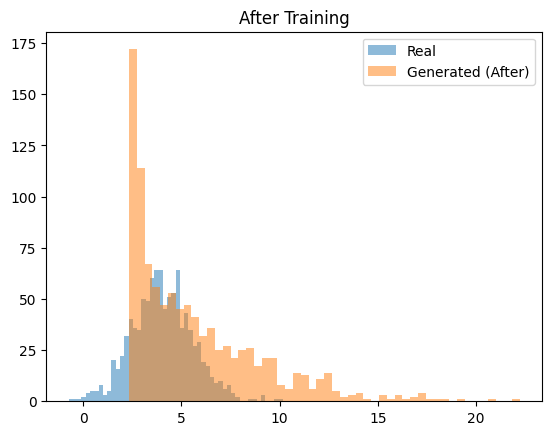

In [72]:
z = torch.randn(1000, 1)
generated_after = G(z).detach()

print("After Training:")
print(f"Mean: {generated_after.mean().item():.3f}")
print(f"Std: {generated_after.std().item():.3f}")

plt.hist(real_dataset.numpy(), bins=50, alpha=0.5, label="Real")
plt.hist(generated_after.numpy(), bins=50, alpha=0.5, label="Generated (After)")

plt.legend()
plt.title("After Training")
plt.show()

In [73]:
with torch.no_grad():
    d_output = D(generated_after)

print("Avg D(G(z)):", d_output.mean().item())

Avg D(G(z)): 0.4151589572429657
